In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import *
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [4]:
import numpy as np

def holm_bonferroni(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    adj = (n - np.arange(n)) * ranked
    adj = np.maximum.accumulate(adj)  # enforce monotonicity
    adj = np.clip(adj, 0, 1)

    pvals_adj = np.empty_like(adj)
    pvals_adj[order] = adj #reorder to original order
    return pvals_adj


In [45]:
# Setup paths
curr_dir = os.getcwd()
# Assuming the notebook is in snnTorch/generalization_madrid
SPIKES_ROOT = os.path.join(curr_dir, "data")
DATA_FILE = os.path.join(SPIKES_ROOT, "power_analysis_results_center_peak.pkl")

print(f"Looking for data at: {DATA_FILE}")

if not os.path.exists(DATA_FILE):
    print("Data file not found. Please run power_analysis.py first.")
else:
    with open(DATA_FILE, 'rb') as f:
        all_power_data = pickle.load(f)
    print(f"Loaded data for keys: {list(all_power_data.keys())}")

Looking for data at: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch\generalization_madrid\data\power_analysis_results_center_peak.pkl
Loaded data for keys: [('adapt20_3b', 20), ('dsb4updn_median_200_11b', 20), ('dsb4updn_median_200_11f', 20), ('dsb4updn_median_200_12b', 20), ('dsb4updn_median_200_13f', 20), ('dsb4updn_median_200_14b', 20), ('dsb4updn_median_200_15f', 20), ('dsb4updn_median_200_16b', 20), ('dsb4updn_median_200_9f', 20), ('updnb4ds_100_13b', 20), ('updnb4ds_100_13f', 20), ('updnb4ds_100_7', 20)]


In [46]:
freq=10000 # Define frequency variable
cut_snippets=50 # Define cut_snippets variable (ms)
def prepare_dataframe(all_power_data):
    records = []
    
    for (network, adapt), events in all_power_data.items():
        for event_type in ['TP', 'FP', 'FN']:
            snippets = events[event_type]
            for s in snippets:
                if len(s) == 0: continue
                # Trim snippets
                s = s[cut_snippets*freq//1000 : -cut_snippets*freq//1000]
                # Calculate metrics
                peak_power = np.max(s)
                mean_power = np.mean(s)
                
                records.append({
                    'Network': network,
                    'Adapt': adapt,
                    'Type': event_type,
                    'Peak Power': peak_power,
                    'Mean Power': mean_power,
                    'Trace': s
                })
    
    return pd.DataFrame(records)

if os.path.exists(DATA_FILE):
    df = prepare_dataframe(all_power_data)
    print(f"Created DataFrame with {len(df)} records")
    display(df.head())

Created DataFrame with 16329 records


,Network,Adapt,Type,Peak Power,Mean Power,Trace
0,adapt20_3b,20,TP,25.816340,2.326112,"[-0.07661251181300337, -0.07870824755995055, -..."
1,adapt20_3b,20,TP,23.850346,2.643514,"[-0.10685728989041057, -0.1066232987683599, -0..."
2,adapt20_3b,20,TP,18.660643,1.557811,"[-0.0691192859442922, -0.06729791776639836, -0..."
3,adapt20_3b,20,TP,48.315762,12.338803,"[11.471415955695008, 11.605240242645849, 11.73..."
4,adapt20_3b,20,TP,21.587914,1.535398,"[-0.10480019580403764, -0.10504114668141212, -..."


In [47]:
stats_df=df.copy()
measures=['Peak Power', 'Mean Power']

# Create a summary table with mean, std, and count for each measure
summary_table = stats_df.groupby("Type")[measures].agg(['mean', 'median','std', 'count']).round(2)

display(summary_table)

Peak Power                     Mean Power                   
           mean median    std count       mean median   std count
Type                                                             
FN         8.14   6.61   5.85  1566       1.19   0.92  0.97  1566
FP         7.57   5.67   6.93  5433       1.13   0.86  1.20  5433
TP        15.69  13.33  10.21  9330       2.36   1.84  1.86  9330

In [51]:
from scipy.stats import mannwhitneyu

def plot_power(vtype="Peak Power"):
    if not os.path.exists(DATA_FILE) or df.empty:
        return

    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Define order for consistency
    order = ['TP', 'FP', 'FN']
    colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
    
    # Aggregate plot
    sns.violinplot(data=df, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)
    # sns.stripplot(data=df, x='Type', y=vtype, order=order, ax=ax, color="black", alpha=0.2, jitter=True, s=3)
    
    # Statistical testing
    print(f"Statistical Significance (Mann-Whitney U Test) - {vtype}:")
    
    # Get distributions
    tp_vals = df[df['Type'] == 'TP'][vtype]
    fp_vals = df[df['Type'] == 'FP'][vtype]
    fn_vals = df[df['Type'] == 'FN'][vtype]
    
    # Prepare heights and centers for annotation
    max_tp = tp_vals.max() if not tp_vals.empty else 0
    max_fp = fp_vals.max() if not fp_vals.empty else 0
    max_fn = fn_vals.max() if not fn_vals.empty else 0
    
    heights = [max_tp, max_fp, max_fn]
    centers = [0, 1, 2]

    p_vals = []
    comparisons = []

    # Compare TP (0) vs FP (1)
    if len(tp_vals) > 0 and len(fp_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fp_vals)
        p_vals.append(p)
        comparisons.append((0, 1, "TP vs FP"))

    # Compare FP (1) vs FN (2)
    if len(fp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(fp_vals, fn_vals)
        p_vals.append(p)
        comparisons.append((1, 2, "FP vs FN"))

    # Compare TP (0) vs FN (2)
    if len(tp_vals) > 0 and len(fn_vals) > 0:
        stat, p = mannwhitneyu(tp_vals, fn_vals)
        p_vals.append(p)
        comparisons.append((0, 2, "TP vs FN"))

  

    # Apply Holm-Bonferroni correction
    if p_vals:
        p_vals_adj = holm_bonferroni(p_vals)
        
        for i, p in enumerate(p_vals_adj):
            heights=[h+0.020*(i)*h for h in heights]
            idx1, idx2, label = comparisons[i]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"{label}: p-value = {p:.4e} ({sig})")
            barplot_annotate_brackets(idx1, idx2, p, centers, heights, ax, barh=0.00, maxasterix=3)

    ax.set_title(f'{vtype} Distribution', fontsize=16)
    ax.set_ylabel(f'{vtype} (z-score)', fontsize=14)
    ax.set_xlabel('', fontsize=14)
    ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(1.3)
    ax.spines[['right', 'top']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=13)
    # ax.grid(True, alpha=0.1)
    ax.grid(False)
    
    plt.show()
    return fig,ax

Statistical Significance (Mann-Whitney U Test) - Peak Power:
TP vs FP: p-value = 0.0000e+00 (***)
FP vs FN: p-value = 9.4921e-13 (***)
TP vs FN: p-value = 1.4433e-231 (***)


C:\Users\NCN\AppData\Local\Temp\ipykernel_24640\3053965298.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)


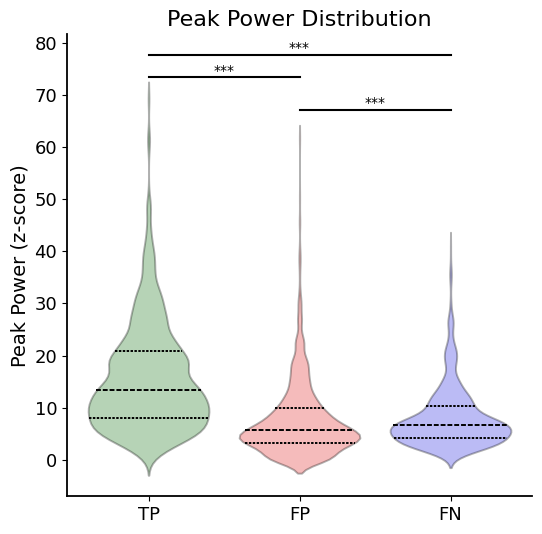

In [52]:
fig,ax=plot_power(vtype="Peak Power")
fig.savefig("peak_power_violin_plot.svg")

C:\Users\NCN\AppData\Local\Temp\ipykernel_24640\3053965298.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y=vtype, order=order, inner="quartile", ax=ax, palette=colors, alpha=0.3, linecolor="black", linewidth=1.4)


Statistical Significance (Mann-Whitney U Test) - Mean Power:
TP vs FP: p-value = 0.0000e+00 (***)
FP vs FN: p-value = 3.7487e-08 (***)
TP vs FN: p-value = 8.1867e-179 (***)


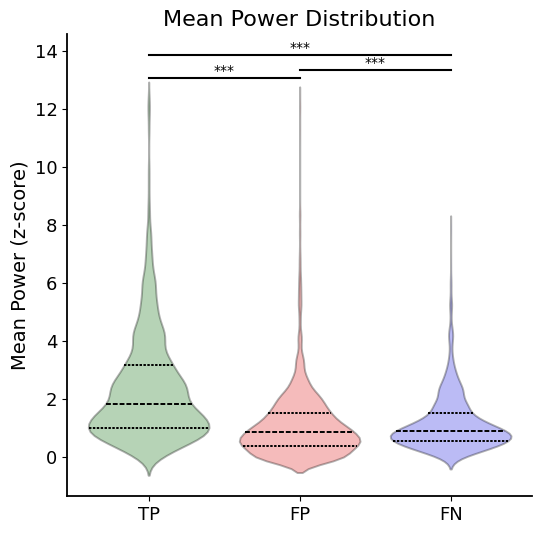

In [53]:
fig,ax=plot_power(vtype="Mean Power")
fig.savefig("mean_power_violin_plot.svg")

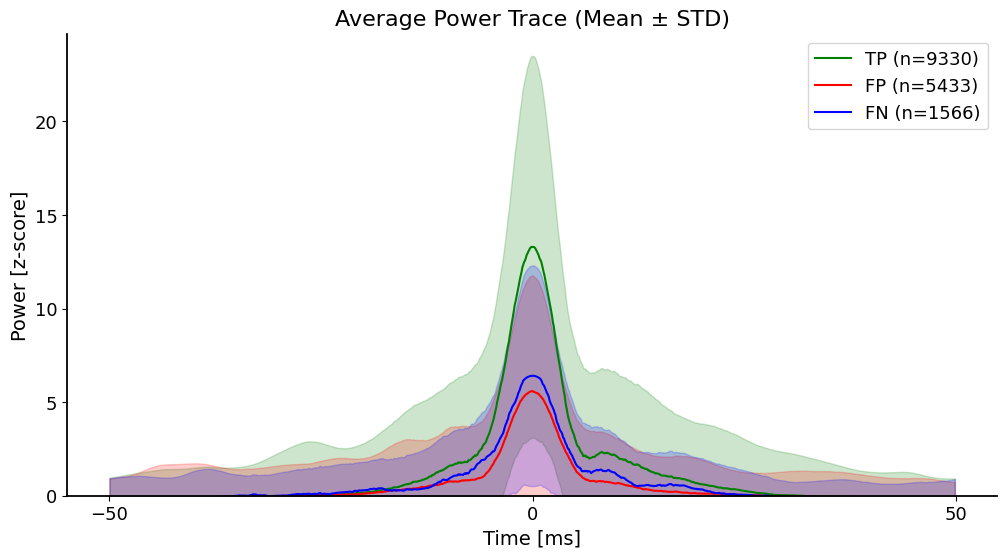

In [56]:
# 3. Power Trace Analysis (Whole Window)
if os.path.exists(DATA_FILE) and not df.empty:
    # Function to plot traces with CI
    def plot_traces(data_df, title_suffix=""):
        fig,ax=plt.subplots(figsize=(12,6))
        
        event_types = ['TP', 'FP', 'FN']
        colors = {'TP': 'green', 'FP': 'red', 'FN': 'blue'}
        
        # Check trace length from first record
        trace_len = len(data_df.iloc[0]['Trace'])

        x_axis = np.arange(trace_len)/10-50  # Convert to milliseconds, centered at 0
        
        for et in event_types:
            subset = data_df[data_df['Type'] == et]
            if subset.empty: continue
            
            # Stack traces: (N_samples, Time_points)
            traces = np.stack(subset['Trace'].values)
            
            # mean_trace = np.mean(traces, axis=0)
            mean_trace = np.median(traces, axis=0)
            std_trace = np.std(traces, axis=0)
            
            # 95% CI approx
            ci = 1.96 * std_trace / np.sqrt(len(traces))
            
            # Using STD for visualization as requested
            upper = mean_trace + std_trace
            lower = mean_trace - std_trace
            lower = np.maximum(lower, 0)
            
            ax.plot(x_axis, mean_trace, label=f'{et} (n={len(traces)})', color=colors[et])
            ax.fill_between(x_axis, lower, upper, color=colors[et], alpha=0.2)
            
        ax.set_title(f'Average Power Trace (Mean ± STD)',fontsize=16)
        ax.set_xlabel('Time [ms]', fontsize=14)
        ax.set_ylabel('Power [z-score]', fontsize=14)
        ax.legend(fontsize=13)
        # ax.grid(True, alpha=0.2)
        ax.grid(False)
        # ax.set_xticks(np.arange(-100, 101, 50))
        ax.set_xticks(np.arange(-50, 51, 50))
        ax.tick_params(axis='both', which='major', labelsize=13)
        ax.spines[['left', 'bottom', 'right', 'top']].set_linewidth(1.3)
        ax.spines[['right', 'top']].set_visible(False)
        ax.set_ylim(bottom=0)
        plt.show()
        return fig,ax

    # Plot aggregated across all networks/adapts
    fig,ax=plot_traces(df, title_suffix="(Aggregated)")
    fig.savefig("power_traces_aggregated.svg")